In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/interaction_type_bout.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/interaction_type_bout.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/interaction_type_bout.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

df['day'] = df['file'].str[:10]


si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


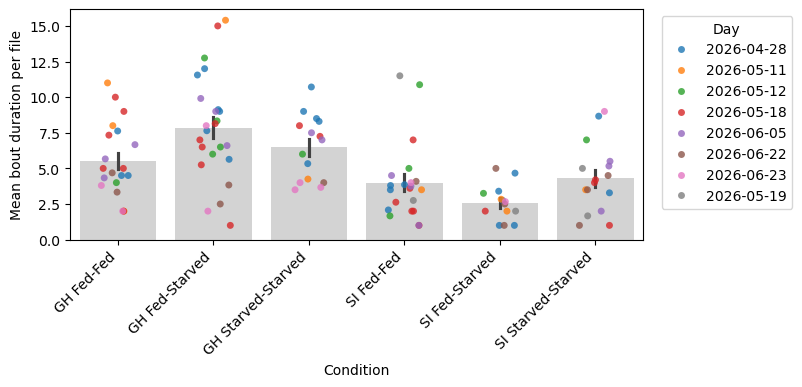

In [2]:
# mean bout duration per file
duration_per_file = (
    df.groupby(['Condition', 'file'])['duration']
      .mean()
      .reset_index(name='mean_bout_duration')
)
duration_per_file['day'] = duration_per_file['file'].str[:10]

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=duration_per_file,
    x='Condition',
    y='mean_bout_duration',
    color='lightgrey',
    errorbar='se'
)

sns.stripplot(
    data=duration_per_file,
    x='Condition',
    y='mean_bout_duration',
    hue='day',
    dodge=False,
    jitter=0.18,
    alpha=0.8,
    size=5,
    ax=ax
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean bout duration per file')
plt.xlabel('Condition')

plt.legend(title='Day', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()